# Excitations

This Python notebook showcases the available pressure excitations. Available excitation types:
 * no_excitation
 * sinusoid
 * two_sinusoids
 * square

Excitations are controled by 4 control parameters:
 * **excitation_type**: One of the above types as string, e.g.: `"sinusoid"`
 * **excitation_cycles**: Number of cycles the excitation lasts. For *no_excitation*, this parameter is irrelevant. Otherwise, the exitation lasts for *excitation_cycles / freq* seconds. In case of *two_sinusoids*, *freq1* is used.
 * **ramp_up_cycles**: Number of cycles for the ramp-up phase. For *no_excitation*, this parameter is irrelevant. The condition *0 <= ramp_up_cycles <= excitation_cycles / 2* should be satisfied.
 * **excitation parameters**: depending on excitation type, different parameters are needed. See below for details. In this notebook, they are passed as keyword arguments. However, in the C++ code, they are passed as an array of doubles, and the order matters.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
def _tukey_window(t, freq, excitation_cycles, ramp_up_cycles):
    ramp_up_cycles = min(ramp_up_cycles, excitation_cycles/2)
    t_end = excitation_cycles / freq
    t_ramp = ramp_up_cycles / freq
    
    if t < 0 or t > t_end:
        return 0.0, 0.0
    elif t < t_ramp:
        p = 0.5 * (1 - np.cos(np.pi * t / t_ramp))
        p_dot = 0.5 * (np.pi / t_ramp) * np.sin(np.pi * t / t_ramp)
        return p, p_dot
    elif t > t_end - t_ramp:
        p = 0.5 * (1 - np.cos(np.pi * (t_end - t) / t_ramp))
        p_dot = 0.5 * (np.pi / t_ramp) * np.sin(np.pi * (t_end - t) / t_ramp)
        return p, p_dot
    else:
        return 1.0, 0.0


def _sin(t, p_A, freq, phase_shift):
    p = p_A * np.sin(2*np.pi*freq*t + phase_shift)
    p_dot = 2*np.pi*freq*p_A * np.cos(2*np.pi*freq*t + phase_shift)
    return p, p_dot


def excitation(t, excitation_type='sin', excitation_cycles=1.0, ramp_up_cycles=0.0, **kwargs):
    if excitation_cycles <= 0.0:
        raise ValueError(f'{excitation_cycles=} must be positive')
    if ramp_up_cycles < 0.0:
        raise ValueError(f'{ramp_up_cycles=} must be non-negative')
    if ramp_up_cycles > excitation_cycles / 2.0:
        raise ValueError(f'{ramp_up_cycles=} must be less than or equal to excitation_cycles / 2.0')
    
    if excitation_type == 'no_excitation':
        return 0.0, 0.0
    
    elif excitation_type == 'sinusoid':
        p_A = kwargs.get('p_A')
        freq = kwargs.get('freq')
        if not (p_A and freq):
            raise ValueError('Missing excitation parameters for sinusoid excitation:\n * p_A: pressure amplitude [Pa]\n * freq: frequency [Hz]')
        if freq <= 0.0:
            raise ValueError(f'{freq=} must be positive')

        p, p_dot = _sin(t, p_A, freq, phase_shift=0.0)
        w, w_dot = _tukey_window(t, freq, excitation_cycles, ramp_up_cycles)
        return p * w, p_dot * w + p * w_dot
    
    elif excitation_type == 'two_sinusoids':
        p_A1 = kwargs.get('p_A1')
        p_A2 = kwargs.get('p_A2')
        freq1 = kwargs.get('freq1')
        freq2 = kwargs.get('freq2')
        phase_shift = kwargs.get('phase_shift', 0.0)
        if not (p_A1 and p_A2 and freq1 and freq2):
            raise ValueError('Missing excitation parameters for two_sinusoids excitation:\n * p_A1: pressure amplitude of first sinusoid [Pa]\n * p_A2: pressure amplitude of second sinusoid [Pa]\n * freq1: frequency of first sinusoid [Hz]\n * freq2: frequency of second sinusoid [Hz]\n * phase_shift: phase shift of second sinusoid [rad] (default: 0.0)')
        if freq1 <= 0.0:
            raise ValueError(f'{freq1=} must be positive')
        if freq2 <= 0.0:
            raise ValueError(f'{freq2=} must be positive')
        
        p1, p1_dot = _sin(t, p_A1, freq1, phase_shift=0.0)
        p2, p2_dot = _sin(t, p_A2, freq2, phase_shift=phase_shift)
        w, w_dot = _tukey_window(t, freq1, excitation_cycles, ramp_up_cycles)

        return w * (p1 + p2), w * (p1_dot + p2_dot) + w_dot * (p1 + p2)
    
    elif excitation_type == 'square':
        p_A = kwargs.get('p_A')
        freq = kwargs.get('freq')
        harmonics = kwargs.get('harmonics', 1)
        if not (p_A and freq):
            raise ValueError('Missing excitation parameters for square excitation:\n * p_A: pressure amplitude [Pa]\n * freq: frequency [Hz]\n * harmonics: number of odd harmonics to include [-] (default: 1)')
        if freq <= 0.0:
            raise ValueError(f'{freq=} must be positive')
        if harmonics <= 0:
            raise ValueError(f'{harmonics=} must be positive')
        if abs(round(harmonics) - harmonics) > 1e-12:
            raise ValueError(f'{harmonics=} must be an integer value')
        harmonics = round(harmonics)

        w, w_dot = _tukey_window(t, freq, excitation_cycles, ramp_up_cycles)
        p, p_dot = 0.0, 0.0
        for i in range(1, 2*int(harmonics)+1, 2):
            p_i = 4.0 * p_A / (np.pi * i)
            f_i = i * freq
            p_i, p_dot_i = _sin(t, p_i, f_i, phase_shift=0.0)
            p += p_i
            p_dot += p_dot_i
        return w * p, w * p_dot + w_dot * p

    else:
        raise ValueError(f'Unknown excitation_type: {excitation_type}. Available types are: no_excitation, sinusoid, two_sinusoids, square.')

In [3]:
fontsize = 10
linewidth = 1.5
figsize = (6, 3)

def plot_excitation(**kwargs):
    # Get time interval
    if 'freq' in kwargs:
        freq = kwargs.get('freq')
    elif 'freq1' in kwargs:
        freq = kwargs.get('freq1')
    else:
        freq = 30000.0  # Hz
    excitation_cycles = kwargs.get('excitation_cycles', 5.0)
    t_end = (excitation_cycles + 0.6) / freq

    # Compute excitation over time
    t = np.linspace(0.0, t_end, 1000)
    p = np.zeros_like(t)
    p_dot = np.zeros_like(t)
    for i, t_i in enumerate(t):
        p_i, p_dot_i = excitation(t_i, **kwargs)
        p[i] = p_i
        p_dot[i] = p_dot_i
    
    # Plot
    fig, ax = plt.subplots(2, 1, figsize=figsize, sharex=True)
    ax[0].plot(t*1e6, p*1e-5, '-', linewidth=linewidth, color='darkblue')
    ax[0].axvline(0, color='grey', linestyle=':', alpha=0.8)
    ax[0].axvline(excitation_cycles/freq*1e6, color='grey', linestyle=':', alpha=0.8)
    ax[0].set_ylabel(r'$p(t)\ \left[ bar \right]$', fontsize=fontsize)
    ax[0].tick_params(axis='both', labelsize=fontsize)
    ax[0].grid(True, alpha=0.3)

    ax[1].plot(t*1e6, p_dot*1e-8, '-', linewidth=linewidth, color='darkgreen')
    ax[1].axvline(0, color='grey', linestyle=':', alpha=0.8)
    ax[1].axvline(excitation_cycles/freq*1e6, color='grey', linestyle=':', alpha=0.8)
    ax[1].set_ylabel(r'$\dot{p}(t)\ \left[ kbar/s \right]$', fontsize=fontsize)
    ax[1].set_xlabel(r'$t\ \left[ \mu s \right]$', fontsize=fontsize)
    ax[1].tick_params(axis='both', labelsize=fontsize)
    ax[1].grid(True, alpha=0.3)

## 1. No Excitation

**Description**: No pressure excitation is applied. The system remains at rest. You may use the control parameter *ratio* to start the simulation from a non-equilibrium state.


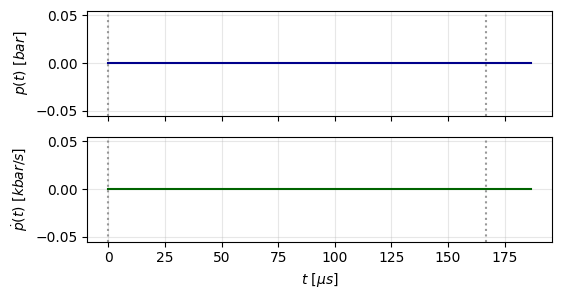

In [4]:
plot_excitation(
# Mandatory:
    excitation_type='no_excitation',
    # rest is irrelevant:
    # excitation_cycles=1.0,
    # ramp_up_cycles=0.0,
# Excitation specific:
    # -
)

## 2. Sinusoid

**Description**: A single sinusoidal pressure excitation.

**Parameters**:
  - **p_A**: Pressure amplitude [Pa].
  - **freq**: Frequency [Hz].

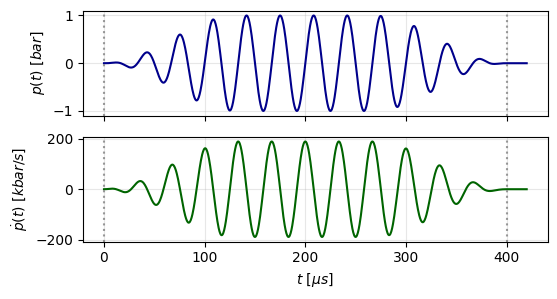

In [5]:
plot_excitation(
# Mandatory:
    excitation_type='sinusoid',
    excitation_cycles=12.0,
    ramp_up_cycles=4.0,
# Excitation specific:
    p_A=1e5,
    freq=30000.0
)

## 3. Two Sinusoids

**Description**: The sum of two sinusoidal pressure excitations with a phase shift. Can be used to achieve various waveforms.

**Parameters**:
  - **p_A1**: Pressure amplitude of the first sinusoid [Pa].
  - **p_A2**: Pressure amplitude of the second sinusoid [Pa].
  - **freq1**: Frequency of the first sinusoid [Hz].
  - **freq2**: Frequency of the second sinusoid [Hz].
  - **phase_shift**: Phase shift of the second sinusoid [rad] (default: 0.0).


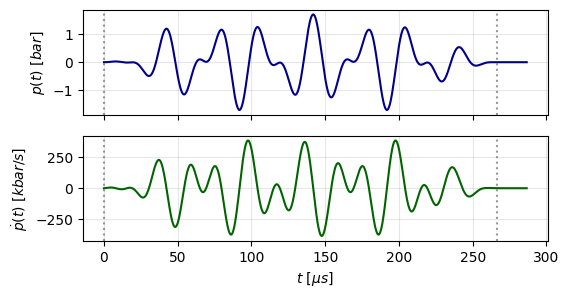

In [6]:
plot_excitation(
# Mandatory:
    excitation_type='two_sinusoids',
    excitation_cycles=8.0,
    ramp_up_cycles=2.0,
# Excitation specific:
    p_A1=1e5,
    p_A2=0.7e5,
    freq1=30000.0,
    freq2=50000.0,
    phase_shift=0.3*np.pi
)

## 4. Square

**Description**: A square wave pressure excitation, approximated by a finite number of harmonics.

**Parameters**:
  - **p_A**: Pressure amplitude [Pa].
  - **freq**: Frequency [Hz].
  - **harmonics**: Number of odd harmonics to include [-] (default: 1).

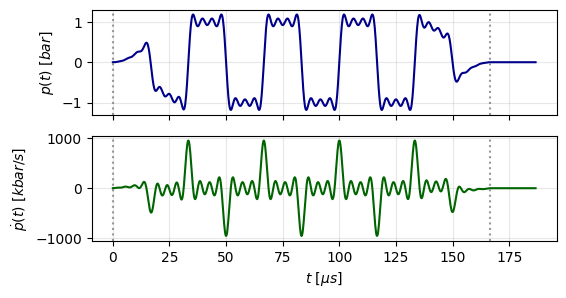

In [7]:
plot_excitation(
# Mandatory:
    excitation_type='square',
    excitation_cycles=5.0,
    ramp_up_cycles=1.0,
# Excitation specific:
    p_A=1e5,
    freq=30000.0,
    harmonics=4
)